In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix)

In [15]:
TH_500 = pd.read_csv(
    "../classification/TomsHardware/Relative_labeling/sigma=500/TomsHardware-Relative-Sigma-500.data",
    sep=",",
    header=None
)

TH_1000= pd.read_csv(
    "../classification/TomsHardware/Relative_labeling/sigma=1000/TomsHardware-Relative-Sigma-1000.data",
    sep=",",
    header=None
)
TH_1500= pd.read_csv(
    "../classification/TomsHardware/Relative_labeling/sigma=1500/TomsHardware-Relative-Sigma-1500.data",
    sep=",",
    header=None
)
groups = [
    "NCD", "BL", "NAD", "AI", "NAC", "ND",
    "CS", "AT", "NA", "ADL", "AS_NA", "AS_NAC"
]

columns = []
for group in groups:
    for t in range(8):
        columns.append(f"{group}_{t}")

columns.append("label")  

TH_500.columns = columns
TH_1000.columns = columns
TH_1500.columns = columns

prefixes = {col.split("_")[0] for col in TH_500.columns if "_" in col}
prefixes = {col.split("_")[0] for col in TH_1000.columns if "_" in col}
prefixes = {col.split("_")[0] for col in TH_1500.columns if "_" in col}

### 500

###  1. Baseline XGBoost

In [16]:
X = TH_500.drop(columns=['label'])
y = TH_500['label']

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, stratify=y,random_state=42)

In [4]:
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss').fit(X_train, y_train)


y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:,1]

print("1. Baseline XGBoost")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

1. Baseline XGBoost
Accuracy: 0.9228336495888678
Precision: 0.8174157303370787
Recall: 0.8362068965517241
F1-score: 0.8267045454545454
ROC-AUC: 0.968964118913779
Confusion Matrix:
[[1168   65]
 [  57  291]]


### 2. XGBoost with Grid Search

In [17]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

grid_search_xgb = GridSearchCV( xgb,param_grid,cv=5,scoring='f1',n_jobs=-1).fit(X_train, y_train)

best_xgb = grid_search_xgb.best_estimator_

y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:,1]

print("2. XGBoost with Grid Search")
print("Best parameters:", grid_search_xgb.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

2. XGBoost with Grid Search
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.8}
Accuracy: 0.9323213156230234
Precision: 0.8472622478386167
Recall: 0.8448275862068966
F1-score: 0.8460431654676259
ROC-AUC: 0.9727465950722936


### 3. XGBoost with scale_pos_weight and Grid Search

In [13]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos
print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 3.5398420674802584


In [15]:
xgb = XGBClassifier(random_state=42,use_label_encoder=False,eval_metric='logloss',scale_pos_weight=scale_pos_weight)

grid_search_xgb_weighted = GridSearchCV(xgb,param_grid,cv=5,scoring='f1',n_jobs=-1).fit(X_train, y_train)


best_xgb_weighted = grid_search_xgb_weighted.best_estimator_

y_pred = best_xgb_weighted.predict(X_test)
y_prob = best_xgb_weighted.predict_proba(X_test)[:,1]



print("3. XGBoost with scale_pos_weight and Grid Search")
print("Best parameters:", grid_search_xgb_weighted.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

3. XGBoost with scale_pos_weight and Grid Search
Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.8}
Accuracy: 0.9133459835547122
Precision: 0.7529976019184652
Recall: 0.9022988505747126
F1-score: 0.8209150326797385
ROC-AUC: 0.9718819625061758
Confusion Matrix:
[[1130  103]
 [  34  314]]


### XGBoost Random Search

In [5]:

xgb = XGBClassifier(random_state=42,eval_metric='logloss',use_label_encoder=False)

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.3, 0.5],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 1.5, 2]
}

random_search = RandomizedSearchCV(xgb, param_distributions=param_dist, n_iter=30,  scoring='f1', cv=5,verbose=1,random_state=42,n_jobs=-1).fit(X_train, y_train)

best_xgb_rand = random_search.best_estimator_

print("Best parameters:", random_search.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters: {'subsample': 0.8, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 0.8}


In [6]:
y_pred = best_xgb_rand.predict(X_test)
y_prob = best_xgb_rand.predict_proba(X_test)[:,1]

print("XGBoost Random Search")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

XGBoost Random Search
Accuracy: 0.9285262492093611
Precision: 0.836676217765043
Recall: 0.8390804597701149
F1: 0.8378766140602583
ROC-AUC: 0.972448285184253


In [12]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.arange(0.3, 0.7, 0.01)

best_f1 = 0
best_t = 0

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t)
    
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best threshold:", best_t)
print("Best F1:", best_f1)

Best threshold: 0.4100000000000001
Best F1: 0.8413793103448276


In [2]:
import pandas as pd

data = [
    ["Baseline XGBoost", 0.9228, 0.8174, 0.8362, 0.8267, 0.9690],
    ["XGBoost Grid Search", 0.9323, 0.8473, 0.8448, 0.8460, 0.9727],
    ["XGBoost scale_pos_weight + Grid", 0.9133, 0.7530, 0.9023, 0.8209, 0.9719],
    ["XGBoost Random Search", 0.9285, 0.8367, 0.8391, 0.8379, 0.9724],
    ["XGBoost (Best Threshold)", None, None, None, 0.8414, None],
]

columns = ["Model", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

df = pd.DataFrame(data, columns=columns)

df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Baseline XGBoost,0.9228,0.8174,0.8362,0.8267,0.9690
1,XGBoost Grid Search,0.9323,0.8473,0.8448,0.8460,0.9727
2,XGBoost scale_pos_weight + Grid,0.9133,0.7530,0.9023,0.8209,0.9719
3,XGBoost Random Search,0.9285,0.8367,0.8391,0.8379,0.9724
4,XGBoost (Best Threshold),NaN,NaN,NaN,0.8414,NaN


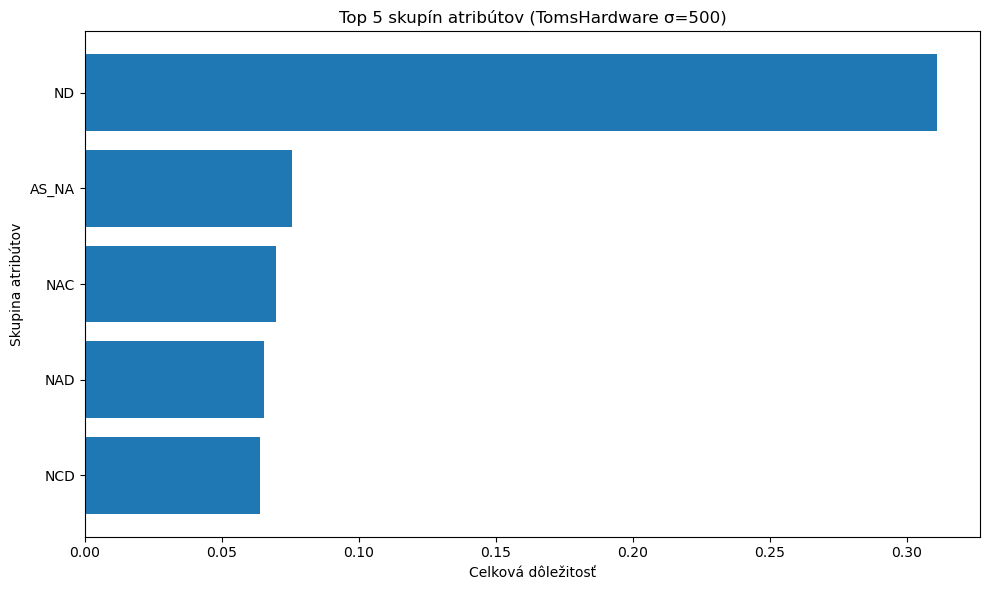

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

importances = best_xgb.feature_importances_
feature_names = X_train.columns

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

feat_imp['base_feature'] = feat_imp['feature'].apply(lambda x: x.rsplit('_', 1)[0])

grouped_importance = feat_imp.groupby('base_feature')['importance'].sum().reset_index()
grouped_importance = grouped_importance.sort_values(by='importance', ascending=False)
top_grouped = grouped_importance.head(5)

plt.figure(figsize=(10, 6))
plt.barh(top_grouped['base_feature'], top_grouped['importance'])
plt.gca().invert_yaxis()

# Заголовок словацькою для TomsHardware σ=500
plt.title("Top 5 skupín atribútov (TomsHardware σ=500)")
plt.xlabel("Celková dôležitosť")
plt.ylabel("Skupina atribútov")

plt.tight_layout()
plt.show()

### 1000

###  1. Baseline XGBoost

In [19]:
X = TH_1000.drop(columns=['label'])
y = TH_1000['label']

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, stratify=y,random_state=42)

In [14]:
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss').fit(X_train, y_train)


y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:,1]

print("1. Baseline XGBoost")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

1. Baseline XGBoost
Accuracy: 0.946236559139785
Precision: 0.8186046511627907
Recall: 0.7927927927927928
F1-score: 0.8054919908466819
ROC-AUC: 0.9774443317489675
Confusion Matrix:
[[1320   39]
 [  46  176]]


### 2. XGBoost with Grid Search

In [20]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

grid_search_xgb = GridSearchCV( xgb,param_grid,cv=5,scoring='f1',n_jobs=-1).fit(X_train, y_train)

best_xgb = grid_search_xgb.best_estimator_

y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:,1]

print("2. XGBoost with Grid Search")
print("Best parameters:", grid_search_xgb.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

2. XGBoost with Grid Search
Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.8}
Accuracy: 0.9430740037950665
Precision: 0.8142857142857143
Recall: 0.7702702702702703
F1-score: 0.7916666666666666
ROC-AUC: 0.9795888603835625


### 3. XGBoost with scale_pos_weight and Grid Search

In [19]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos
print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 6.121621621621622


In [20]:
xgb = XGBClassifier(random_state=42,use_label_encoder=False,eval_metric='logloss',scale_pos_weight=scale_pos_weight)

grid_search_xgb_weighted = GridSearchCV(xgb,param_grid,cv=5,scoring='f1',n_jobs=-1).fit(X_train, y_train)


best_xgb_weighted = grid_search_xgb_weighted.best_estimator_

y_pred = best_xgb_weighted.predict(X_test)
y_prob = best_xgb_weighted.predict_proba(X_test)[:,1]



print("3. XGBoost with scale_pos_weight and Grid Search")
print("Best parameters:", grid_search_xgb_weighted.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

3. XGBoost with scale_pos_weight and Grid Search
Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 200, 'subsample': 1.0}
Accuracy: 0.9443390259329538
Precision: 0.7838983050847458
Recall: 0.8333333333333334
F1-score: 0.8078602620087336
ROC-AUC: 0.9784552764685216
Confusion Matrix:
[[1308   51]
 [  37  185]]


### XGBoost Random Search

In [15]:

xgb = XGBClassifier(random_state=42,eval_metric='logloss',use_label_encoder=False)

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.3, 0.5],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 1.5, 2]
}

random_search = RandomizedSearchCV(xgb, param_distributions=param_dist, n_iter=30,  scoring='f1', cv=5,verbose=1,random_state=42,n_jobs=-1).fit(X_train, y_train)

best_xgb_rand = random_search.best_estimator_

print("Best parameters:", random_search.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters: {'subsample': 0.9, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 1.0}


In [16]:
y_pred = best_xgb_rand.predict(X_test)
y_prob = best_xgb_rand.predict_proba(X_test)[:,1]

print("XGBoost Random Search")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

XGBoost Random Search
Accuracy: 0.948134092346616
Precision: 0.8240740740740741
Recall: 0.8018018018018018
F1: 0.8127853881278538
ROC-AUC: 0.9798772282215991


In [17]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.arange(0.3, 0.7, 0.01)

best_f1 = 0
best_t = 0

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t)
    
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best threshold:", best_t)
print("Best F1:", best_f1)

Best threshold: 0.38000000000000006
Best F1: 0.8141592920353983


In [1]:
import pandas as pd

data = [
    ["Baseline XGBoost", 0.9462, 0.8186, 0.7928, 0.8055, 0.9774],
    ["XGBoost Grid Search", 0.9431, 0.8143, 0.7703, 0.7917, 0.9796],
    ["XGBoost scale_pos_weight + Grid", 0.9443, 0.7839, 0.8333, 0.8079, 0.9785],
    ["XGBoost Random Search", 0.9481, 0.8241, 0.8018, 0.8128, 0.9799],
    ["XGBoost (Best Threshold)", None, None, None, 0.8142, None],
]

columns = ["Model", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

df = pd.DataFrame(data, columns=columns)

df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Baseline XGBoost,0.9462,0.8186,0.7928,0.8055,0.9774
1,XGBoost Grid Search,0.9431,0.8143,0.7703,0.7917,0.9796
2,XGBoost scale_pos_weight + Grid,0.9443,0.7839,0.8333,0.8079,0.9785
3,XGBoost Random Search,0.9481,0.8241,0.8018,0.8128,0.9799
4,XGBoost (Best Threshold),NaN,NaN,NaN,0.8142,NaN


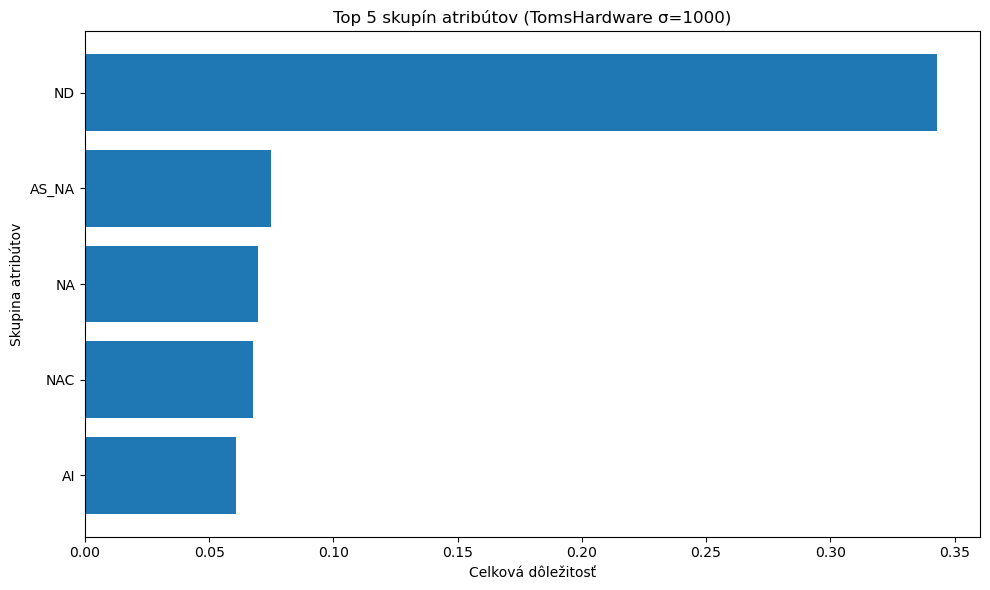

In [21]:
importances = best_xgb.feature_importances_
feature_names = X_train.columns

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

feat_imp['base_feature'] = feat_imp['feature'].apply(lambda x: x.rsplit('_', 1)[0])

grouped_importance = feat_imp.groupby('base_feature')['importance'].sum().reset_index()
grouped_importance = grouped_importance.sort_values(by='importance', ascending=False)
top_grouped = grouped_importance.head(5)

plt.figure(figsize=(10, 6))
plt.barh(top_grouped['base_feature'], top_grouped['importance'])
plt.gca().invert_yaxis()

plt.title("Top 5 skupín atribútov (TomsHardware σ=1000)")
plt.xlabel("Celková dôležitosť")
plt.ylabel("Skupina atribútov")

plt.tight_layout()
plt.show()

### 1500

###  1. Baseline XGBoost

In [22]:
X = TH_1500.drop(columns=['label'])
y = TH_1500['label']

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, stratify=y,random_state=42)

In [19]:
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss').fit(X_train, y_train)


y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:,1]

print("1. Baseline XGBoost")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

1. Baseline XGBoost
Accuracy: 0.967741935483871
Precision: 0.8774193548387097
Recall: 0.8095238095238095
F1-score: 0.8421052631578947
ROC-AUC: 0.9886386614093622
Confusion Matrix:
[[1394   19]
 [  32  136]]


### 2. XGBoost with Grid Search

In [23]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

grid_search_xgb = GridSearchCV( xgb,param_grid,cv=5,scoring='f1',n_jobs=-1).fit(X_train, y_train)

best_xgb = grid_search_xgb.best_estimator_

y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:,1]

print("2. XGBoost with Grid Search")
print("Best parameters:", grid_search_xgb.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

2. XGBoost with Grid Search
Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
Accuracy: 0.9652118912080961
Precision: 0.8553459119496856
Recall: 0.8095238095238095
F1-score: 0.8318042813455657
ROC-AUC: 0.9893590132443636


### 3. XGBoost with scale_pos_weight and Grid Search

In [24]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos
print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 8.396731054977712


In [25]:
xgb = XGBClassifier(random_state=42,use_label_encoder=False,eval_metric='logloss',scale_pos_weight=scale_pos_weight)

grid_search_xgb_weighted = GridSearchCV(xgb,param_grid,cv=5,scoring='f1',n_jobs=-1).fit(X_train, y_train)


best_xgb_weighted = grid_search_xgb_weighted.best_estimator_

y_pred = best_xgb_weighted.predict(X_test)
y_prob = best_xgb_weighted.predict_proba(X_test)[:,1]



print("3. XGBoost with scale_pos_weight and Grid Search")
print("Best parameters:", grid_search_xgb_weighted.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

3. XGBoost with scale_pos_weight and Grid Search
Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 200, 'subsample': 1.0}
Accuracy: 0.9683744465528147
Precision: 0.8390804597701149
Recall: 0.8690476190476191
F1-score: 0.8538011695906432
ROC-AUC: 0.9899656253159438
Confusion Matrix:
[[1385   28]
 [  22  146]]


### XGBoost Random Search

In [20]:

xgb = XGBClassifier(random_state=42,eval_metric='logloss',use_label_encoder=False)

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.3, 0.5],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 1.5, 2]
}

random_search = RandomizedSearchCV(xgb, param_distributions=param_dist, n_iter=30,  scoring='f1', cv=5,verbose=1,random_state=42,n_jobs=-1).fit(X_train, y_train)

best_xgb_rand = random_search.best_estimator_

print("Best parameters:", random_search.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters: {'subsample': 0.9, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 1.0}


In [21]:
y_pred = best_xgb_rand.predict(X_test)
y_prob = best_xgb_rand.predict_proba(X_test)[:,1]

print("XGBoost Random Search")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

XGBoost Random Search
Accuracy: 0.9652118912080961
Precision: 0.8553459119496856
Recall: 0.8095238095238095
F1: 0.8318042813455657
ROC-AUC: 0.9892494860647728


In [22]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.arange(0.3, 0.7, 0.01)

best_f1 = 0
best_t = 0

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t)
    
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best threshold:", best_t)
print("Best F1:", best_f1)

Best threshold: 0.4300000000000001
Best F1: 0.8408408408408409


In [3]:
import pandas as pd

data = [
    ["Baseline XGBoost", 0.9677, 0.8774, 0.8095, 0.8421, 0.9886],
    ["XGBoost Grid Search", 0.9652, 0.8553, 0.8095, 0.8318, 0.9894],
    ["XGBoost scale_pos_weight + Grid", 0.9684, 0.8391, 0.8690, 0.8538, 0.9900],
    ["XGBoost Random Search", 0.9652, 0.8553, 0.8095, 0.8318, 0.9892],
    ["XGBoost (Best Threshold)", None, None, None, 0.8408, None],
]

columns = ["Model", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

df = pd.DataFrame(data, columns=columns)

df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Baseline XGBoost,0.9677,0.8774,0.8095,0.8421,0.9886
1,XGBoost Grid Search,0.9652,0.8553,0.8095,0.8318,0.9894
2,XGBoost scale_pos_weight + Grid,0.9684,0.8391,0.8690,0.8538,0.9900
3,XGBoost Random Search,0.9652,0.8553,0.8095,0.8318,0.9892
4,XGBoost (Best Threshold),NaN,NaN,NaN,0.8408,NaN


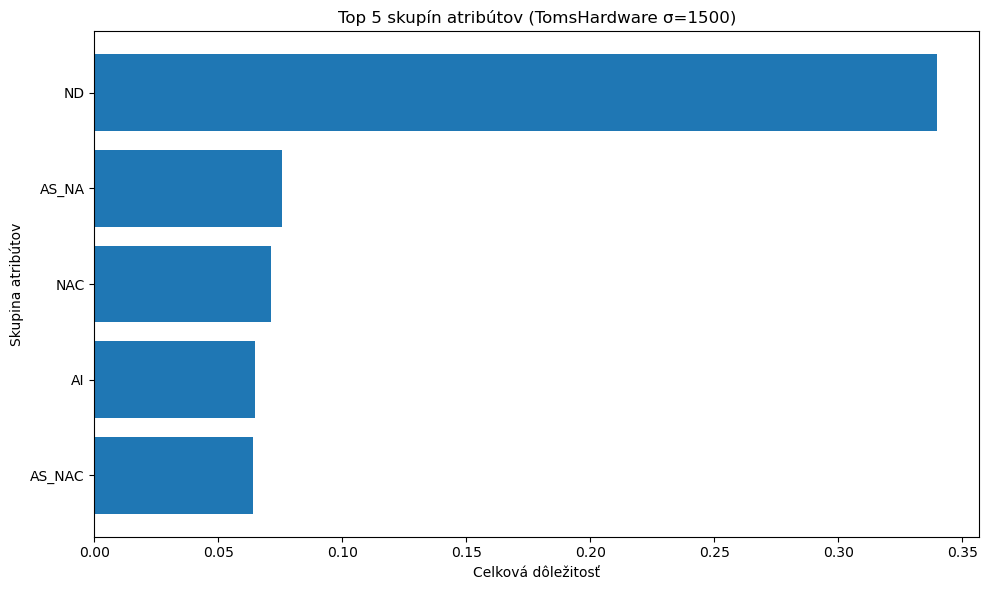

In [24]:
importances = best_xgb.feature_importances_
feature_names = X_train.columns

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

feat_imp['base_feature'] = feat_imp['feature'].apply(lambda x: x.rsplit('_', 1)[0])

grouped_importance = feat_imp.groupby('base_feature')['importance'].sum().reset_index()
grouped_importance = grouped_importance.sort_values(by='importance', ascending=False)
top_grouped = grouped_importance.head(5)

plt.figure(figsize=(10, 6))
plt.barh(top_grouped['base_feature'], top_grouped['importance'])
plt.gca().invert_yaxis()

plt.title("Top 5 skupín atribútov (TomsHardware σ=1500)")
plt.xlabel("Celková dôležitosť")
plt.ylabel("Skupina atribútov")

plt.tight_layout()
plt.show()

### Result 

Získané výsledky ukázali, že XGBoost vykazuje vysokú a stabilnú kvalitu klasifikácie na všetkých troch datasetoch. Aj základný model bez dodatočnej optimalizácie poskytuje vysoké hodnoty accuracy, F1-score a ROC-AUC, čo svedčí o schopnosti modelu efektívne odhaľovať zložité nelineárne závislosti v dátach.
Pre dataset TH_500 najlepšie výsledky preukázal model XGBoost s Grid Search, ktorý dosiahol najvyššiu hodnotu F1-score a ROC-AUC, čo svedčí o optimálnej rovnováhe medzi precision a recall. Použitie parametra scale_pos_weight umožnilo výrazne zvýšiť recall, avšak na úkor zníženia precision.
Pre dataset TH_1000 základný model XGBoost už vykazuje veľmi vysoké výsledky a dodatočná optimalizácia hyperparametrov nevedie k výraznému zlepšeniu. V tomto prípade najlepšia rovnováha medzi metrikami sa dosahuje pri použití scale_pos_weight, čo umožňuje zlepšiť detekciu udalostí buzz.
Pre najnevyváženejší dataset TH_1500 najefektívnejším sa ukázal model XGBoost s prihliadnutím na váhy tried, ktorý zabezpečil najvyššie hodnoty F1-score a ROC-AUC. To potvrdzuje, že pri výraznej nevyváženosti tried je obzvlášť dôležité zohľadniť váhu pozitívnej triedy.
Celkovo možno konštatovať, že optimalizácia hyperparametrov je najefektívnejšia pre menej nevyvážené dáta (σ = 500), zatiaľ čo pri rastúcej nevyváženosti (σ = 1000, 1500) kľúčovú úlohu zohráva zohľadnenie váh tried pomocou parametra scale_pos_weight.
Model XGBoost teda predstavuje efektívny nástroj pre úlohu predikcie buzz, pričom jeho najlepšia konfigurácia závisí od miery nevyváženosti dát: pri miernej nevyváženosti je vhodné použiť optimalizáciu parametrov, zatiaľ čo pri výraznej nevyváženosti — metódy zohľadnenia váh tried.